# Task 1: Predict Restaurant Ratings (Regression)

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

## 2. Load Dataset

In [3]:
df=pd.read_csv("D:\B.tech\sem_5\ML\ML_internship_project\Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## 3. Explore Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

## Missing Values

In [5]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

## 4. Data Cleaning

In [6]:
df=df.drop_duplicates()
for col in df.select_dtypes(include='object').columns:
 df[col]=df[col].fillna(df[col].mode()[0])
for col in df.select_dtypes(include=np.number).columns:
 df[col]=df[col].fillna(df[col].median())

## 5. Feature Selection

In [7]:
target='Aggregate rating'
drop=[c for c in ['Restaurant ID','Restaurant Name','Rating text'] if c in df.columns]
X=df.drop(columns=drop+[target])
y=df[target]

## 6. Encode Categorical Variables

In [8]:
le=LabelEncoder()
for col in X.select_dtypes(include='object').columns:
 X[col]=le.fit_transform(X[col].astype(str))

## 7. Train Test Split

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Linear Regression

In [11]:
model=LinearRegression()
model.fit(X_train,y_train)
pred=model.predict(X_test)
print('MAE',mean_absolute_error(y_test,pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,pred)))
print('R2',r2_score(y_test,pred))

MAE 0.9904423763659833
RMSE 1.1865019147129836
R2 0.3814941201800013


## Decision Tree

In [12]:
model=DecisionTreeRegressor(random_state=42)
model.fit(X_train,y_train)
pred=model.predict(X_test)
print('MAE',mean_absolute_error(y_test,pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,pred)))
print('R2',r2_score(y_test,pred))

MAE 0.1468864468864469
RMSE 0.23190111391554263
R2 0.9763727805372109


## Random Forest

In [13]:
model=RandomForestRegressor(random_state=42)
model.fit(X_train,y_train)
pred=model.predict(X_test)
print('MAE',mean_absolute_error(y_test,pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,pred)))
print('R2',r2_score(y_test,pred))

MAE 0.11568027210884349
RMSE 0.16814923382271119
R2 0.9875778510802682


## Feature Importance

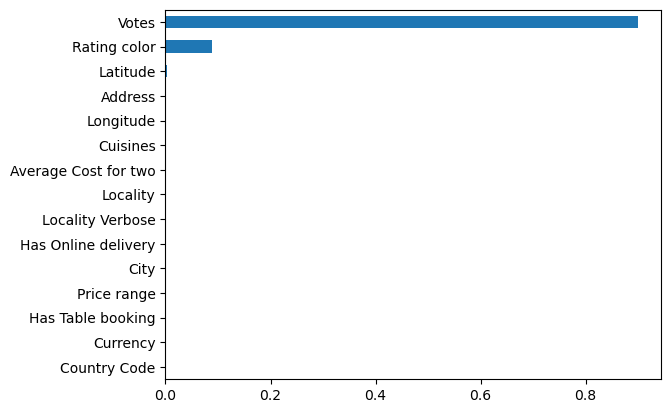

In [14]:
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
imp=pd.Series(rf.feature_importances_,index=X.columns).sort_values().tail(15)
imp.plot(kind='barh')
plt.show()

## Conclusion